In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file1 = "vgsales.csv"
file2 = "games.csv"
vgsales = pd.read_csv(file1)
games = pd.read_csv(file2)

In [3]:
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
games.head()

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


In [5]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


In [6]:
vgsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [7]:
games.isna().sum()

Unnamed: 0            0
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [8]:
vgsales.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
vgsales.dropna(inplace = True)
games.dropna(inplace = True)

In [10]:
vgsales.isna().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [11]:
vgsales['Genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [12]:
vgsales['Year'].mode()

0    2009.0
Name: Year, dtype: float64

In [13]:
len(vgsales['Name'].unique())

11325

In [14]:
pub = vgsales['Name'].unique()
pub2 = []
for i in range(0, vgsales['Name'].nunique()):
    pub2.append(pub[i])


In [15]:
pub2.sort()

In [16]:
len(pub2)

11325

In [17]:
type(games['Plays'][1])

str

In [18]:
def parse_number(x):
    x = x.lower().strip()
    if x.endswith("k"):
        return float(x[:-1]) * 1000
    else:
        return float(x)

In [19]:
games['Plays'] = games['Plays'].apply(parse_number).astype(int)

In [20]:
games['Plays']

0       17000
1       21000
2       30000
3       28000
4       21000
        ...  
1507      763
1508     1500
1509     1100
1510      269
1511     1700
Name: Plays, Length: 1498, dtype: int64

In [21]:
games['Playing'] = games['Playing'].apply(parse_number).astype(int)
games['Playing']

0       3800
1       3200
2       2500
3        679
4       2400
        ... 
1507       5
1508      49
1509      45
1510      79
1511      11
Name: Playing, Length: 1498, dtype: int64

In [22]:
games.head(1)

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17000,3800,4.6K,4.8K


In [23]:
for i in ['Backlogs','Wishlist','Times Listed', 'Number of Reviews']:
    games[i] = games[i].apply(parse_number).astype(int)

In [24]:
unique_values = (
    games["Genres"]
    .apply(ast.literal_eval)   # convert string → list
    .explode()                 # flatten lists
    .dropna()
    .unique()
)

In [25]:
len(unique_values)

23

In [26]:
adventure = games["Genres"].apply(
    lambda x: "Adventure" in ast.literal_eval(x)
)

In [27]:
j = []
for i in unique_values:
    j.append(games['Genres'].apply(lambda x: i in ast.literal_eval(x)))


In [28]:
genres = pd.DataFrame(dict(zip(unique_values, j)))

In [29]:
genres['Title'] = games['Title']

In [30]:
genres.to_csv('genres')

In [31]:
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [32]:
salesgnr = vgsales['Genre']
salesgnr = salesgnr.astype(str)

In [33]:
salesgnr = salesgnr.unique()

In [34]:
salesgnr.sort()
salesgnr

array(['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle',
       'Racing', 'Role-Playing', 'Shooter', 'Simulation', 'Sports',
       'Strategy'], dtype=object)

In [35]:
unique_values.sort()
unique_values

array(['Adventure', 'Arcade', 'Brawler', 'Card & Board Game', 'Fighting',
       'Indie', 'MOBA', 'Music', 'Pinball', 'Platform', 'Point-and-Click',
       'Puzzle', 'Quiz/Trivia', 'RPG', 'Racing', 'Real Time Strategy',
       'Shooter', 'Simulator', 'Sport', 'Strategy', 'Tactical',
       'Turn Based Strategy', 'Visual Novel'], dtype=object)

In [36]:
duplicate1 = games[games.duplicated()]

In [37]:
duplicate1

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist


In [38]:
duplicate2 = vgsales[vgsales['Name'].duplicated()]

In [39]:
vgsales.head(1)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74


In [40]:
cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for i in cols:
    vgsales[i] = vgsales[i] * 1000000

In [41]:
vgsales.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41490000.0,29020000.0,3770000.0,8460000.0,82740000.0
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29080000.0,3580000.0,6810000.0,770000.0,40240000.0
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15850000.0,12880000.0,3790000.0,3310000.0,35820000.0
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15750000.0,11010000.0,3280000.0,2960000.0,33000000.0
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11270000.0,8890000.0,10220000.0,1000000.0,31370000.0


In [42]:
vgsales.to_csv("vgsales")
games.to_csv("games")


In [43]:
file = "/home/pushkar/DA/Labmentix/Proj2/cleaned/games.csv"
df = pd.read_csv(file)

In [44]:
concat = pd.concat([vgsales, games], axis = 1)

In [45]:
concat.shape

(16305, 25)

In [46]:
concat.dropna(inplace = True)
concat.shape

(1484, 25)

In [47]:
concat.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Unnamed: 0',
       'Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist'],
      dtype='object')

                Rating  Global_Sales
Rating        1.000000      0.205779
Global_Sales  0.205779      1.000000


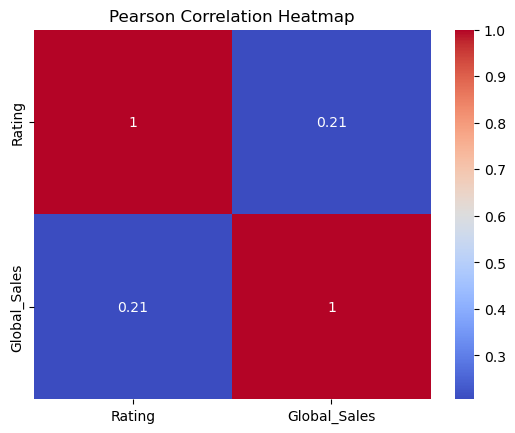

In [48]:
pearson_corr = concat[["Rating", "Global_Sales"]].corr(method='pearson')
print(pearson_corr)

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

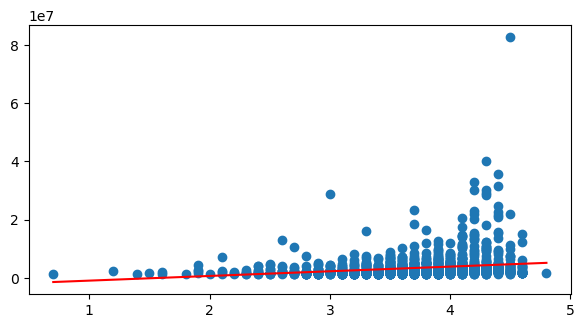

In [49]:
plt.figure(figsize = [7, 3.5])
plt.scatter(concat["Rating"], concat["Global_Sales"])
plt.plot(np.unique(concat["Rating"]), 
         np.poly1d(np.polyfit(concat["Rating"], concat["Global_Sales"], 1))
         (np.unique(concat["Rating"])), color='red')

In [50]:
corr = concat["Global_Sales"].corr(concat["Rating"])

In [51]:
corr

0.20577872179016252

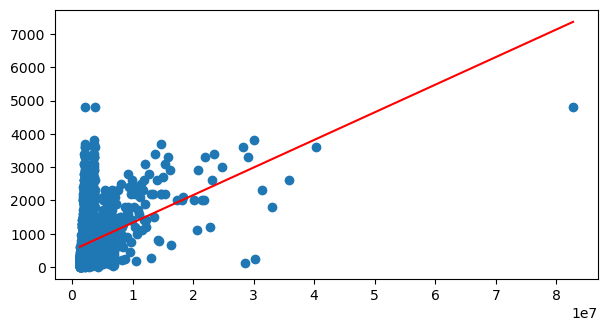

In [52]:
plt.figure(figsize = [7, 3.5])
plt.scatter(concat["Global_Sales"], concat["Wishlist"])
plt.plot(np.unique(concat["Global_Sales"]), 
         np.poly1d(np.polyfit(concat["Global_Sales"], concat["Wishlist"], 1))
         (np.unique(concat["Global_Sales"])), color='red')

In [53]:
corr = concat["Global_Sales"].corr(concat["Wishlist"])

In [54]:
corr

0.4363982230001747

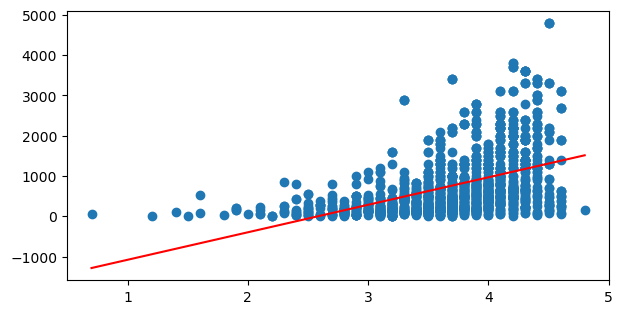

In [55]:
plt.figure(figsize = [7, 3.5])
plt.scatter(concat["Rating"], concat["Wishlist"])
plt.plot(np.unique(concat["Rating"]), 
         np.poly1d(np.polyfit(concat["Rating"], concat["Wishlist"], 1))
         (np.unique(concat["Rating"])), color='red')

In [56]:
corr = concat["Wishlist"].corr(concat["Rating"])

In [57]:
corr

0.4596246369252826

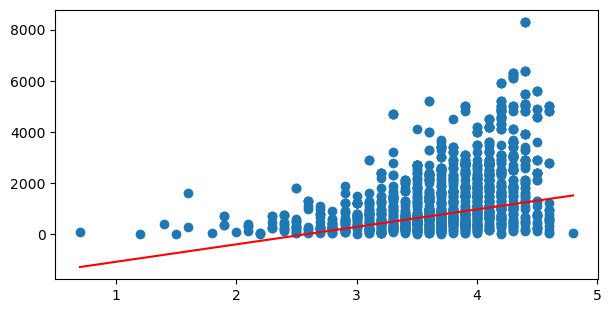

In [58]:
plt.figure(figsize = [7, 3.5])
plt.scatter(concat["Rating"], concat["Backlogs"])
plt.plot(np.unique(concat["Rating"]), 
         np.poly1d(np.polyfit(concat["Rating"], concat["Wishlist"], 1))
         (np.unique(concat["Rating"])), color='red')

In [59]:
corr = concat["Rating"].corr(concat["Backlogs"])
corr

0.43776628556020375